# KC analyst-hard. Homework

## Библиотеки и функции

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from statsmodels.stats.proportion import proportion_confint
from tqdm.notebook import tqdm as tqdm_notebook
from collections import namedtuple
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tqdm.notebook import tqdm
from statsmodels.stats.proportion import proportion_confint
from scipy import stats

In [35]:
def generate_corr_data(N, pre_mean, post_mean, corr = 0.8):
    """Генерируем датафрейм с нужной корреляцией между 2 ковариатами.
    
    N - размер data frame
    pre_mean - средняя до старта теста
    post_mean - средняя после старта теста
    corr - корреляция метрики во время эксперимента с метрикой до эксперимента.
    Возвращает датафрейм с коррелированной метрикой до эксперимента и после эксперимента
    """
    cov = [[1, corr], [corr, 1]]
    correlated_data = np.random.multivariate_normal([pre_mean, post_mean], cov, N)
    correlated_df = pd.DataFrame({'post_value': correlated_data[:, 1], 'pre_value': correlated_data[:, 0]})
    return (correlated_df)


def calculate_theta_basic(pre, post):
    theta = (np.cov(post, pre)[0, 1]) /\
            (np.var(pre))
    return(theta) 
    
    
def calculate_theta_for_test(control_pre, control_post, test_pre, test_post):
    theta = (np.cov(control_post, control_pre)[0, 1] + np.cov(test_post, test_pre)[0, 1]) /\
            (np.var(control_pre) + np.var(test_pre))
    return(theta)

def get_basic_ttest(group_A, group_B):
    '''Проверяет гипотезу о равенстве средних для обычного среднего.
    return - t_stat, p_value'''
    
    t_stat, p_value = stats.ttest_ind(group_A, group_B)
    inference = {'t_stat': t_stat, 'p_value':p_value}
    return(inference)


def get_cuped_ttest(control_pre, control_post, test_pre, test_post):
    '''Проверяет гипотезу о равенстве средних CUPED вариант
    return - t_stat, p_value'''
    
    theta = calculate_theta_for_test(control_pre, control_post, test_pre, test_post)

    control_cuped = control_post - theta * control_pre
    test_cuped = test_post - theta * test_pre
    
    inference = get_basic_ttest(control_cuped, test_cuped)
    
    return(inference)

# Задание

Задание

> Вы работаете аналитиком команды монетизации. Тестируете новую систему цен на очень небольшую аудиторию – профессионалы в небольшом городе.
Аудитория достаточно пассивная, поэтому в ней редко "прокрашиваются" фичи. Каждая потенциальная фича на вес золота.
Менеджеры имеют большие надежды на эту фичу.
Основная метрика ARPPU. Даже такое небольшое повышение позволит начать зарабатывать больше.

Вам нужно
- провести первичный анализ и найти наблюдаемый эффект между группами
- проанализировать базовый A/B-тест и понять есть ли стат. значимое изменение в post данных после внедрения новых цен
- провести CUPED t-test
- рассчитать размер выборки для CUPED t-test

Описание данных

- Данные содержат поюзерную пару ARPPU до теста (pre_ARPPU) и ARPU после тесте (post_ARPU)
- Данные лежат в файле cuped_homework.csv


## EDA

In [3]:
df_exp = pd.read_csv('3 cuped_homework.csv')

In [6]:
print(df_exp.info())
df_exp.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4460 entries, 0 to 4459
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   post_ARPPU  4460 non-null   float64
 1   pre_ARPPU   3867 non-null   float64
 2   group       4460 non-null   object 
dtypes: float64(2), object(1)
memory usage: 104.7+ KB
None


,post_ARPPU,pre_ARPPU,group
0,660.0,595.0,A
1,540.0,621.0,A
2,863.0,782.0,A
3,431.0,567.0,A
4,434.0,473.0,A


In [38]:
df_exp.isna().sum()

post_ARPPU      0
pre_ARPPU     593
group           0
dtype: int64

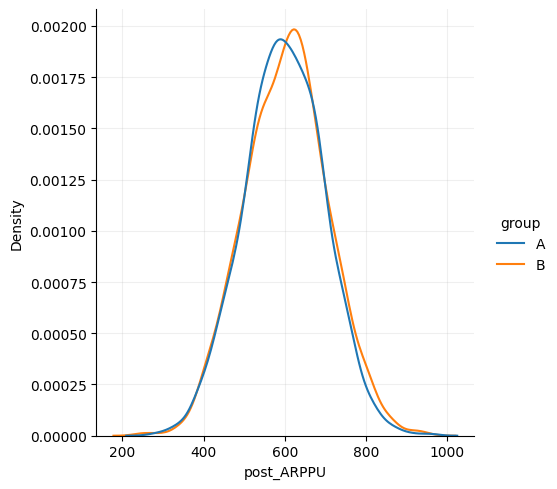

In [91]:
sns.displot(data=df_exp, x='post_ARPPU', hue='group', kind='kde')
plt.grid(alpha=0.2)

<Figure size 1000x1000 with 0 Axes>

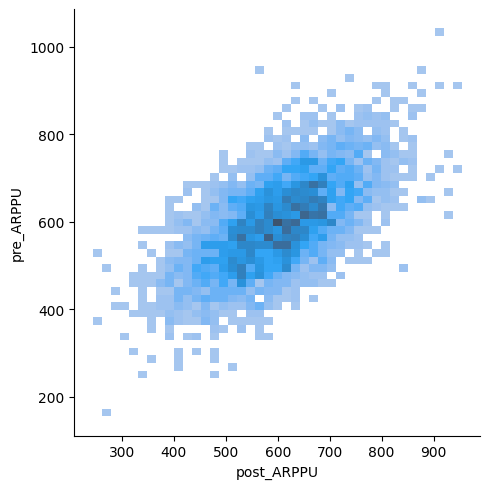

In [11]:
plt.figure(figsize = (10, 10))
sns.displot(df_exp, x="post_ARPPU", y="pre_ARPPU")

In [21]:
df_exp.groupby('group')['post_ARPPU'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2209.0,598.689905,98.092719,273.0,533.0,598.0,667.0,961.0
B,2251.0,604.045757,102.244927,244.0,533.0,606.0,671.0,954.0


In [94]:
agg_exp = df_exp.groupby('group')['post_ARPPU'].mean()
agg_exp

group
A    598.689905
B    604.045757
Name: post_ARPPU, dtype: float64

In [104]:
pre_ARPPU_std = df_exp['pre_ARPPU'].std(skipna=True, ddof=1)

print(f"Размер абсолютного эффекта (B-A): {agg_exp['B'] - agg_exp['A']:.3f}")
print(f"Размер относительного эффекта (B-A): {agg_exp['B'] / agg_exp['A'] - 1:.3%}")
print(f"Размер станд. эффекта (B-A): {(agg_exp['B'] - agg_exp['A']) / pre_ARPPU_std:.4f}")

Размер абсолютного эффекта (B-A): 5.356
Размер относительного эффекта (B-A): 0.895%
Размер станд. эффекта (B-A): 0.0567


## Basic t-test

In [29]:
get_basic_ttest(
    group_A=df_exp.loc[df_exp.group=='A', ['post_ARPPU']],
    group_B=df_exp.loc[df_exp.group=='B', ['post_ARPPU']]
)

{'t_stat': array([-1.78458076]), 'p_value': array([0.07439733])}

## CUPED t-test

In [48]:
print(f"Доля пустых значений в 'pre_ARPPU': {df_exp.pre_ARPPU.isna().sum() / df_exp.pre_ARPPU.count():.2%}")

Доля пустых значений в 'pre_ARPPU': 15.33%


In [81]:
# Среднее для заполнения "pre_ARPPU"
pre_mean = df_exp.pre_ARPPU.mean().round(1)

In [83]:
df_exp = \
(df_exp
 # .iloc[1065:1070]
 .assign(is_pre_na = lambda df: df.pre_ARPPU.isna(),
         pre_ARPPU = lambda df: df.pre_ARPPU.fillna(pre_mean)
 )
)

In [89]:
get_cuped_ttest(
    control_pre=df_exp.loc[df_exp.group=='A', 'pre_ARPPU'],
    control_post=df_exp.loc[df_exp.group=='A', 'post_ARPPU'],
    test_pre=df_exp.loc[df_exp.group=='B', 'pre_ARPPU'],
    test_post=df_exp.loc[df_exp.group=='B', 'post_ARPPU']
)

{'t_stat': np.float64(-2.1493877780310036),
 'p_value': np.float64(0.03165733662313475)}

## Размер выборки для CUPED t-test

- альфа = 0.05 и мощности 0.8
- двусторонняя проверка гипотезы
- размер выборок 50/50
- статистический критерий t-test
- относительный MDE = 0.01
- за основу будем брать другой датасет на исторических данных cuped_homework_pre_pre_data.csv. он имеет похожу схему. только отсутствует деление на группы
- не забываем заполнить пустые занчения средней прежде чем рассчитывать размер группы для CUPED/ Для рассчета обычной выборки пожно использовать post данные на истрическом периоде

**Задания:**
- Задание 4.1. Укажите чему равна theta по важшим рассчетам
- Задание 4.2. Укажите на сколько процентов стандартное отклонение Y_cuped меньше стандартного отклоения post_ARPPU
- Задание 4.3. Укажите размер выборки нужный для детекции такого MDE на post данных простым t-test
- Задание 4.4. Укажите размер выборки нужный для детекции такого MDE CUPED t-test

In [ ]:
alpha = 0.05
power = 0.8
mde_perc = 0.01

In [ ]:
df_pre_pre_data = 